   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

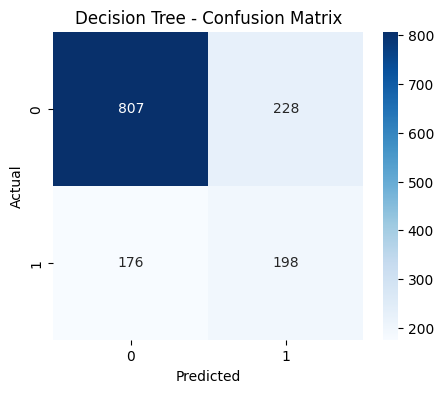


========== Random Forest ==========
Accuracy: 0.7757274662881476

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



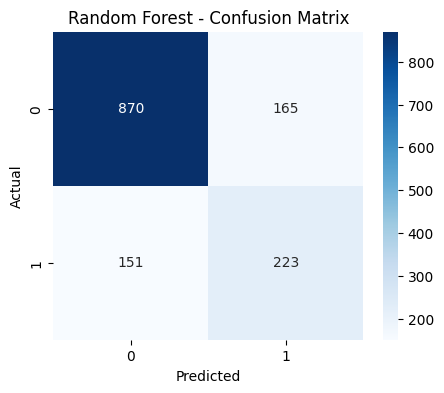


========== XGBoost ==========
Accuracy: 0.7643718949609652

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.56      0.56      0.56       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.76      0.76      1409



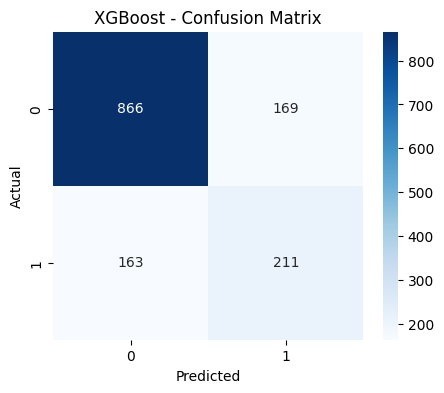


Random Forest CV Accuracy: 0.8445384357166835


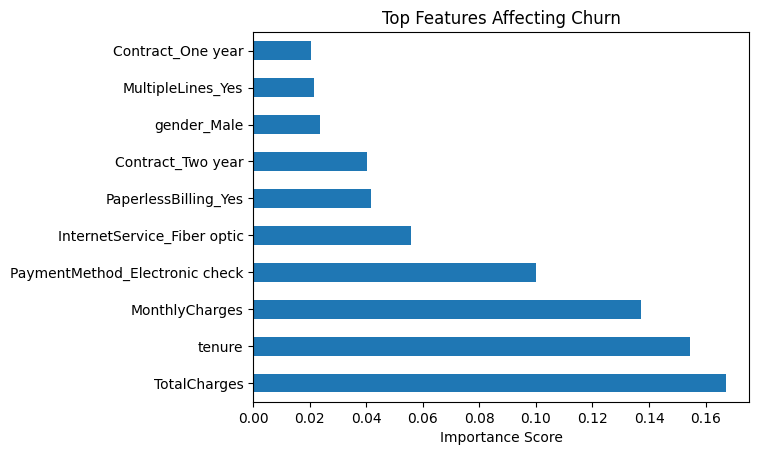


✅ Model saved as churn_model.pkl


In [2]:
# ==================================================
# 1️⃣ IMPORT LIBRARIES
# ==================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==================================================
# 2️⃣ LOAD DATASET
# ==================================================
df = pd.read_csv("Churn_Dataset.csv")

print(df.head())
print(df.info())

# ==================================================
# 3️⃣ DATA CLEANING
# ==================================================
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ==================================================
# 4️⃣ ONE-HOT ENCODING
# ==================================================
df = pd.get_dummies(df, drop_first=True)

print("\nAfter preprocessing:")
print(df.info())

# ==================================================
# 5️⃣ FEATURE / TARGET SPLIT
# ==================================================
X = df.drop("Churn", axis=1)
y = df["Churn"]

# ✅ SAVE COLUMN STRUCTURE (VERY IMPORTANT)
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("✅ columns.pkl saved")

# ==================================================
# 6️⃣ TRAIN TEST SPLIT
# ==================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# 7️⃣ HANDLE IMBALANCE (SMOTE)
# ==================================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

# ==================================================
# 8️⃣ DEFINE MODELS
# ==================================================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# ==================================================
# 9️⃣ TRAIN & EVALUATE
# ==================================================
for name, model in models.items():

    print(f"\n========== {name} ==========")

    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ==================================================
# 🔟 CROSS VALIDATION (RANDOM FOREST)
# ==================================================
rf_model = RandomForestClassifier(random_state=42)

scores = cross_val_score(
    rf_model,
    X_train_resampled,
    y_train_resampled,
    cv=5
)

print("\nRandom Forest CV Accuracy:", scores.mean())

# ==================================================
# 1️⃣1️⃣ TRAIN FINAL MODEL
# ==================================================
rf_model.fit(X_train_resampled, y_train_resampled)

# ==================================================
# 1️⃣2️⃣ FEATURE IMPORTANCE
# ==================================================
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Features Affecting Churn")
plt.xlabel("Importance Score")
plt.show()

# ==================================================
# 1️⃣3️⃣ SAVE MODEL
# ==================================================
with open("churn_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("\n✅ Model saved as churn_model.pkl")